# HBV Calibration: AutoDiff (Adam) vs Local Optimization (L-BFGS-B)

This notebook demonstrates two gradient-based calibration approaches for HBV:

| Method | Gradients from | Model required |
|--------|---------------|----------------|
| **L-BFGS-B** (scipy) | Finite differences — runs HBV N+1 times per step | Original `hbv.py` (numpy) |
| **AutoDiff** (Adam) | Exact — backpropagates through HBV in one pass | `hbv_differentiable.py` (PyTorch) |

### Key conceptual difference

```
L-BFGS-B (finite difference):
  for each parameter pᵢ:
      run HBV with pᵢ + ε  →  loss_plus
      run HBV with pᵢ      →  loss
      ∂loss/∂pᵢ ≈ (loss_plus - loss) / ε   ← approximate, N extra runs

AutoDiff (PyTorch):
      run HBV once          →  loss
      loss.backward()       →  ∂loss/∂p for ALL parameters simultaneously
                               exact, zero extra runs
```

Both are **local** optimizers — they follow gradients downhill from a starting point.
AutoDiff is more scalable: cost does not grow with number of parameters.

## 0. Setup

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import time
from scipy.optimize import minimize
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 14,
                     'axes.labelsize': 13, 'legend.fontsize': 11})

from hbv import hbv_run
from hbv_differentiable import (hbv_run_differentiable, hbv_run_fast,
                                 prepare_forcing, PARAM_NAMES, PARAM_BOUNDS)
from metrics import nse, align_on_time

# Device selection
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

print(f'PyTorch version : {torch.__version__}')
print(f'Device selected : {DEVICE}')

PyTorch version : 2.11.0
Device selected : mps


## 1. Load Data

In [19]:
example_dir = Path('examples') / 'Prof_Amir_AghaKouchak_example'

forcing = pd.read_csv(example_dir / 'inputPrecipTemp.csv')
forcing['Time'] = pd.to_datetime(forcing['Time'])

pet = pd.read_csv(example_dir / 'inputMonthlyTempEvap.csv')

Qobs = pd.read_csv(example_dir / 'Qobs.csv')
Qobs['Time'] = pd.to_datetime(Qobs['Time'])

AREA_KM2  = 410.0
WARMUP    = 365    # skip first year (spin-up)
N_DAYS    = len(forcing)

print(f'Period : {forcing["Time"].min().date()} → {forcing["Time"].max().date()}')
print(f'Days   : {N_DAYS}   |   Warmup: {WARMUP} days')

Period : 1991-01-01 → 2000-12-30
Days   : 3652   |   Warmup: 365 days


In [20]:
# Parameter bounds (same as HBV_calibration.ipynb)
param_bounds = {
    'd'   : (1.0,  5.0),
    'fc'  : (100., 400.),
    'beta': (1.0,  5.0),
    'cpar': (0.01, 0.3),
    'k0'  : (0.1,  0.5),
    'lthr': (1.0,  20.),
    'k1'  : (0.01, 0.2),
    'k2'  : (0.005,0.15),
    'kp'  : (0.01, 0.15),
    'pwp' : (50.,  200.),
}
lower = np.array([param_bounds[p][0] for p in PARAM_NAMES])
upper = np.array([param_bounds[p][1] for p in PARAM_NAMES])
p0    = (lower + upper) / 2.0    # mid-range starting point (same for both methods)

print('Starting parameters (mid-range):')
for name, val in zip(PARAM_NAMES, p0):
    print(f'  {name:6s} = {val:.4f}')

Starting parameters (mid-range):
  d      = 3.0000
  fc     = 250.0000
  beta   = 3.0000
  cpar   = 0.1550
  k0     = 0.3000
  lthr   = 10.5000
  k1     = 0.1050
  k2     = 0.0775
  kp     = 0.0800
  pwp    = 125.0000


## 2. Method A — L-BFGS-B with Finite-Difference Gradients

scipy's `minimize` calls the original **numpy HBV** repeatedly:
- 1 call to evaluate the loss
- N calls (one per parameter) to approximate each gradient via finite difference

```
∂loss/∂pᵢ ≈ [loss(p + εeᵢ) - loss(p)] / ε
```

With 10 parameters → **11 HBV runs per optimizer step**.

In [22]:
fd_call_count = 0   # track how many times HBV is called
fd_loss_history = []

def objective_fd(params):
    """MSE loss for scipy — uses original numpy HBV."""
    global fd_call_count
    fd_call_count += 1

    res, _ = hbv_run(
        forcing=forcing, pet_monthly=pet,
        params=params, area_km2=AREA_KM2,
    )
    obs, sim, _ = align_on_time(res, Qobs)
    obs, sim = obs[WARMUP:], sim[WARMUP:]
    loss = float(np.mean((sim - obs) ** 2))

    # Record loss only on true function evaluations (not finite-diff perturbations)
    # scipy calls objective once per step before the finite-diff gradient sweep
    if fd_call_count % (len(params) + 1) == 1:
        fd_loss_history.append(loss)

    return loss

result_fd = minimize(
    objective_fd,
    x0     = p0,
    method = 'L-BFGS-B',
    bounds = list(param_bounds.values()),
    options= {'maxiter': 200, 'ftol': 1e-9},
)

params_fd = result_fd.x
print(f'L-BFGS-B converged: {result_fd.success}')
print(f'Total HBV calls   : {fd_call_count}')
print(f'Optimizer steps   : {result_fd.nit}')

L-BFGS-B converged: True
Total HBV calls   : 682
Optimizer steps   : 51


## 3. Method B — AutoDiff with Adam

PyTorch's autograd runs the **differentiable HBV** once and backpropagates:
- 1 forward pass → loss
- 1 backward pass → ∂loss/∂p for ALL 10 parameters simultaneously

```
loss.backward()   # exact gradients, always 2 HBV-equivalent passes
```

In [23]:
# Observed discharge as tensor (NaN-safe)
Q_obs_full = torch.tensor(
    pd.merge(forcing[['Time']], Qobs, on='Time', how='left')['Q (m3/s)'].values,
    dtype=torch.float32, device=DEVICE
)
valid = ~torch.isnan(Q_obs_full)
valid[:WARMUP] = False   # exclude warmup from loss

# Parameters with gradients enabled
params_ad = torch.tensor(p0, dtype=torch.float32, requires_grad=True, device=DEVICE)
lb = torch.tensor(lower, dtype=torch.float32, device=DEVICE)
ub = torch.tensor(upper, dtype=torch.float32, device=DEVICE)

optimizer  = torch.optim.Adam([params_ad], lr=0.02)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
N_EPOCHS   = 50
ad_loss_history = []

t0 = time.time()
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()

    Q_sim, _ = hbv_run_differentiable(
        forcing=forcing, pet_monthly=pet,
        params=params_ad, area_km2=AREA_KM2,
        device=DEVICE,
    )

    loss = torch.mean((Q_sim[valid] - Q_obs_full[valid]) ** 2)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())   # reduce lr if loss plateaus

    with torch.no_grad():
        params_ad.clamp_(lb, ub)

    ad_loss_history.append(loss.item())

    if (epoch + 1) % 1 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS}  MSE={loss.item():.4f}  lr={current_lr:.5f}  ({elapsed:.1f}s elapsed)')

params_ad_final = params_ad.detach().cpu().numpy()

Epoch   1/50  MSE=25.9361  lr=0.02000  (4.2s elapsed)
Epoch   2/50  MSE=22.1327  lr=0.02000  (8.2s elapsed)
Epoch   3/50  MSE=18.5519  lr=0.02000  (12.5s elapsed)
Epoch   4/50  MSE=14.9265  lr=0.02000  (16.6s elapsed)
Epoch   5/50  MSE=12.0239  lr=0.02000  (20.7s elapsed)
Epoch   6/50  MSE=11.3246  lr=0.02000  (24.8s elapsed)
Epoch   7/50  MSE=10.7467  lr=0.02000  (28.7s elapsed)
Epoch   8/50  MSE=10.2700  lr=0.02000  (32.8s elapsed)
Epoch   9/50  MSE=9.8784  lr=0.02000  (36.9s elapsed)
Epoch  10/50  MSE=9.5363  lr=0.02000  (40.9s elapsed)
Epoch  11/50  MSE=9.2293  lr=0.02000  (45.0s elapsed)
Epoch  12/50  MSE=9.0064  lr=0.02000  (49.1s elapsed)
Epoch  13/50  MSE=9.0002  lr=0.02000  (53.1s elapsed)
Epoch  14/50  MSE=8.9943  lr=0.02000  (57.2s elapsed)
Epoch  15/50  MSE=8.9886  lr=0.02000  (61.3s elapsed)
Epoch  16/50  MSE=8.9830  lr=0.02000  (65.4s elapsed)
Epoch  17/50  MSE=8.9775  lr=0.02000  (69.4s elapsed)
Epoch  18/50  MSE=8.9723  lr=0.02000  (73.6s elapsed)
Epoch  19/50  MSE=8.96

## 4. Compare Results

In [27]:
# Run both calibrated models
res_fd, _ = hbv_run(forcing=forcing, pet_monthly=pet,
                    params=params_fd, area_km2=AREA_KM2)

with torch.no_grad():
    _, res_ad = hbv_run_differentiable(forcing=forcing, pet_monthly=pet,
                                       params=params_ad, area_km2=AREA_KM2)

# Compute NSE (excluding warmup)
obs_arr,  sim_fd_arr, merged = align_on_time(res_fd, Qobs)
obs_arr,  sim_fd_arr = obs_arr[WARMUP:],  sim_fd_arr[WARMUP:]

obs_arr2, sim_ad_arr, _ = align_on_time(res_ad, Qobs)
obs_arr2, sim_ad_arr = obs_arr2[WARMUP:], sim_ad_arr[WARMUP:]

nse_fd = nse(obs_arr,  sim_fd_arr)
nse_ad = nse(obs_arr2, sim_ad_arr)

print(f"{'Method':<25} {'NSE':>8}")
print('-' * 35)
print(f"{'L-BFGS-B (finite diff)':<25} {nse_fd:>8.4f}")
print(f"{'Adam (AutoDiff)':<25} {nse_ad:>8.4f}")

Method                         NSE
-----------------------------------
L-BFGS-B (finite diff)      0.6824
Adam (AutoDiff)             0.6608


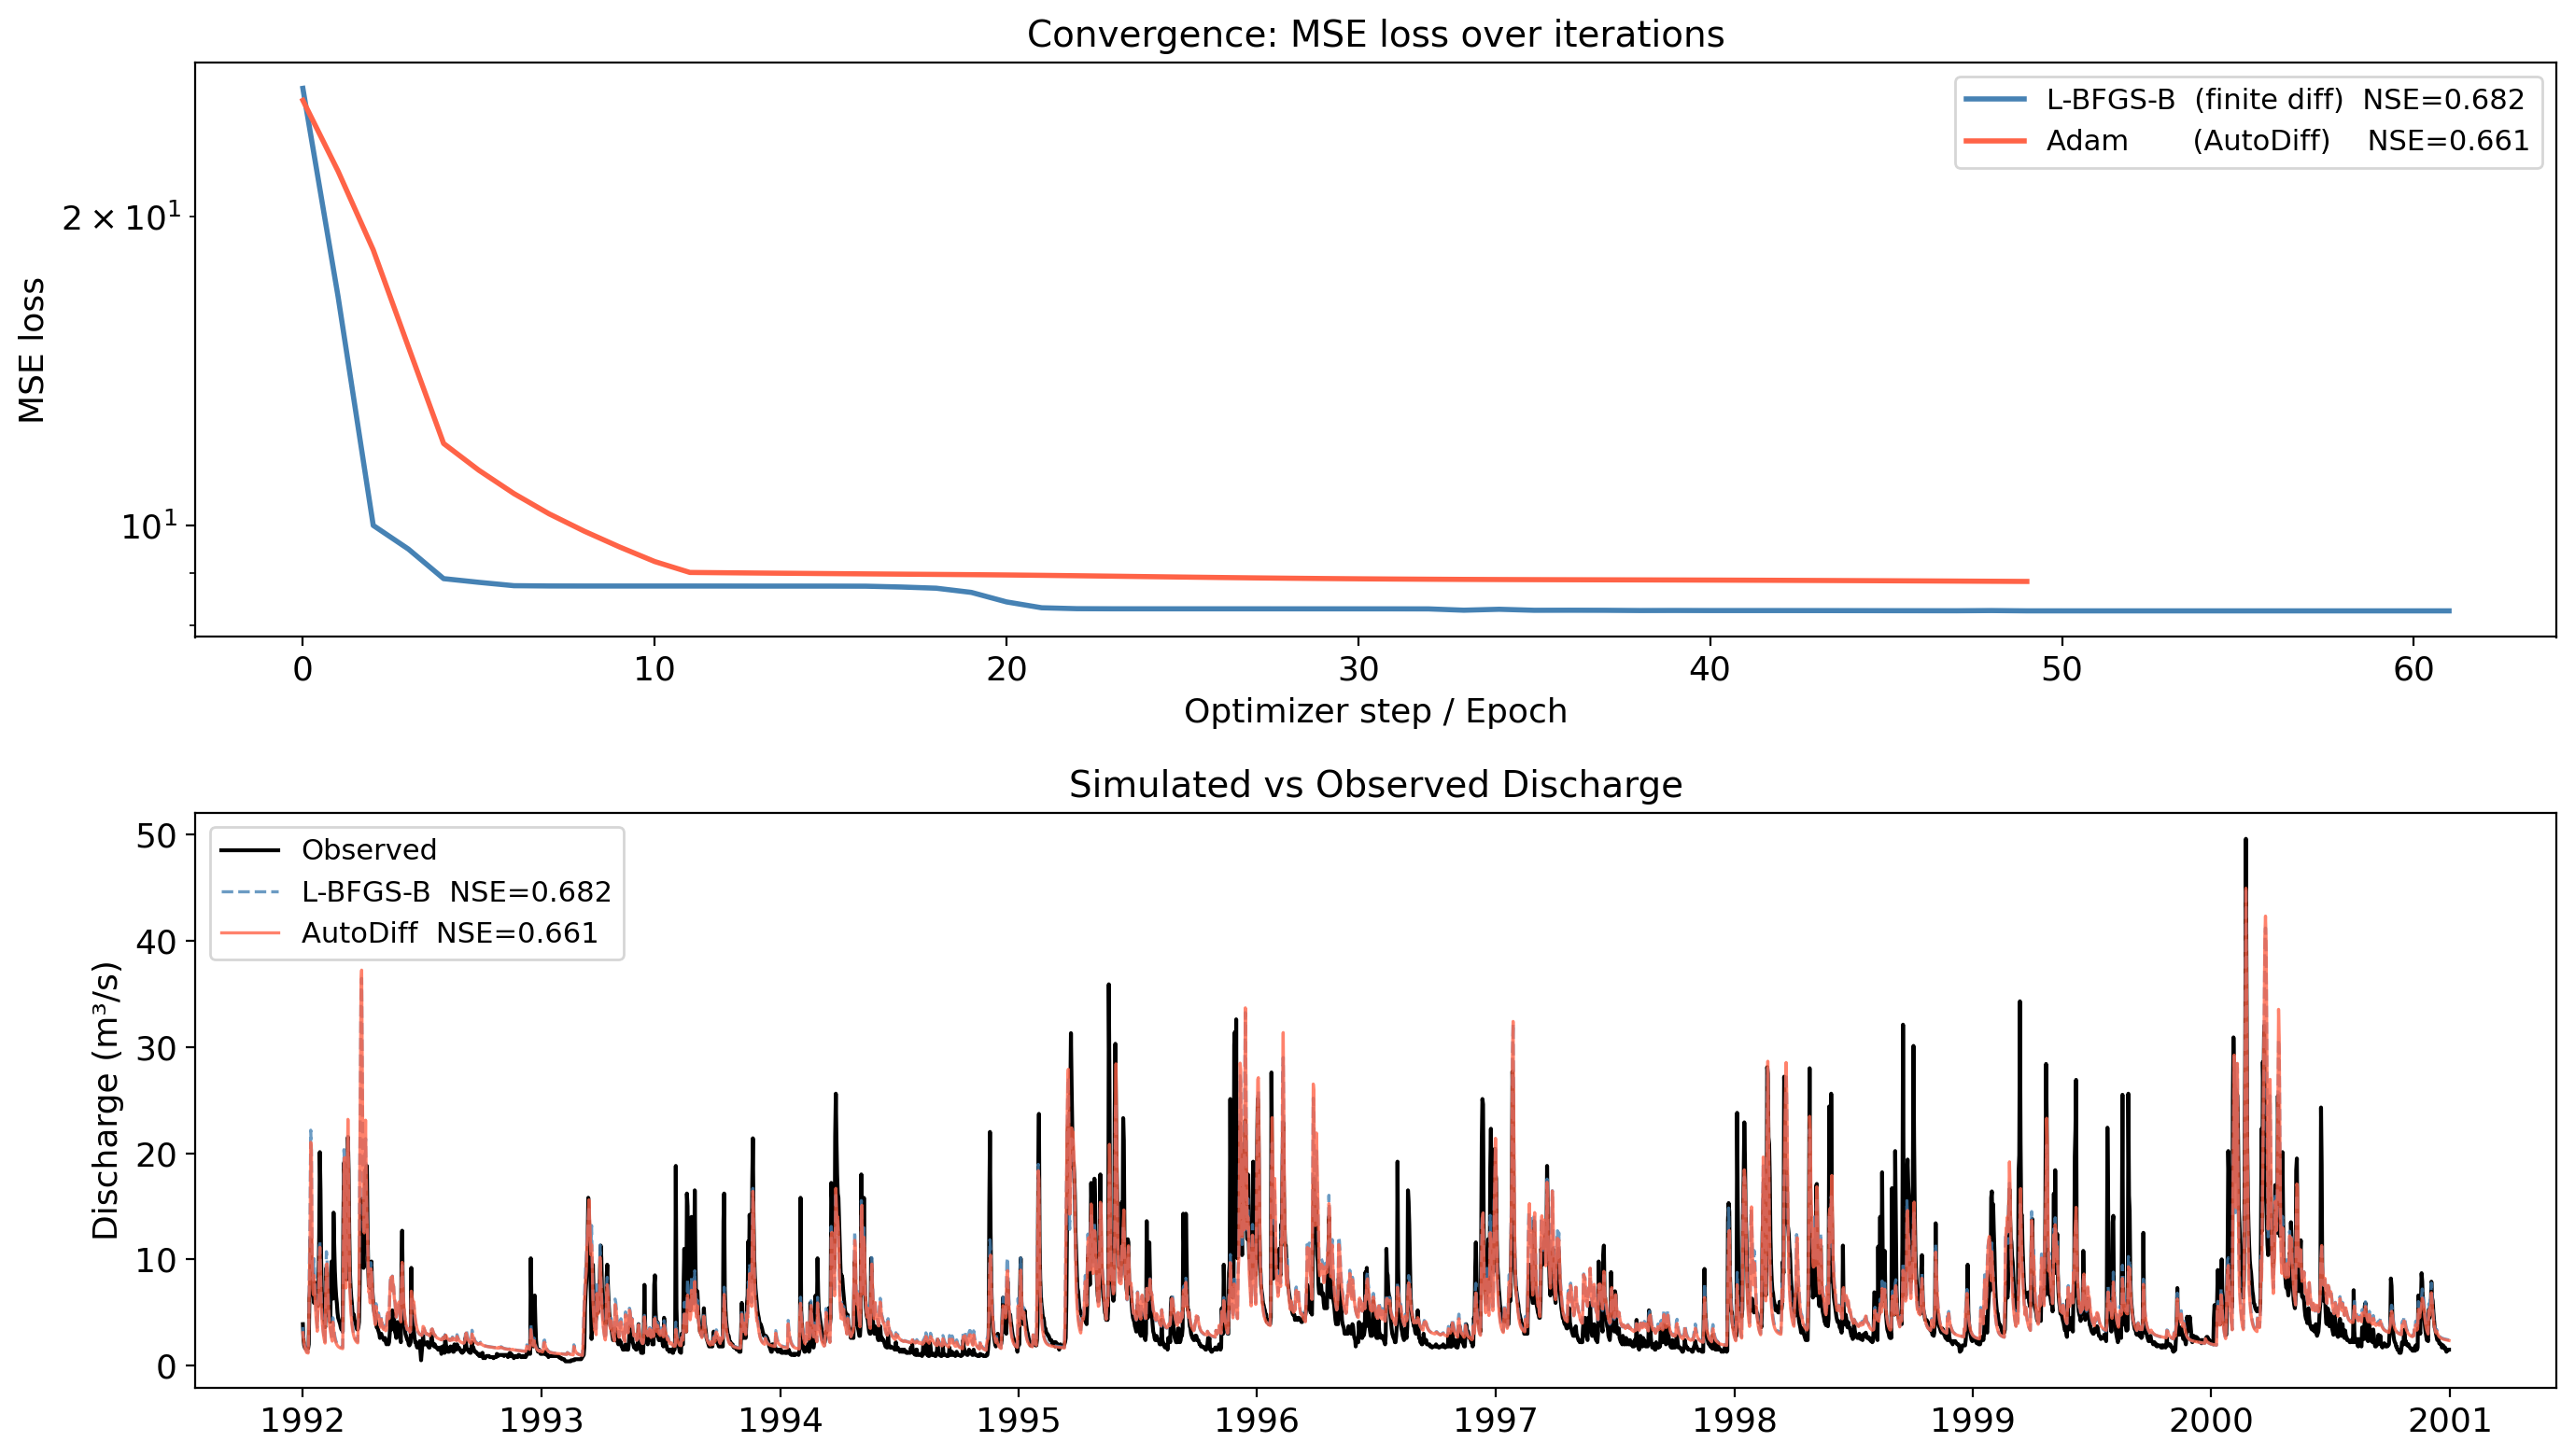

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Panel 1: Convergence ---
ax = axes[0]
ax.plot(fd_loss_history, color='steelblue', lw=2, label=f'L-BFGS-B  (finite diff)  NSE={nse_fd:.3f}')
ax.plot(ad_loss_history, color='tomato',    lw=2, label=f'Adam       (AutoDiff)    NSE={nse_ad:.3f}')
ax.set_xlabel('Optimizer step / Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Convergence: MSE loss over iterations')
ax.legend()
ax.set_yscale('log')

# --- Panel 2: Simulated vs Observed ---
time_plot = merged['Time'].values[WARMUP:]

ax = axes[1]
ax.plot(time_plot, obs_arr,    color='black',     lw=1.5, label='Observed')
ax.plot(time_plot, sim_fd_arr, color='steelblue', lw=1.2,
        alpha=0.8, label=f'L-BFGS-B  NSE={nse_fd:.3f}', linestyle='--')
ax.plot(time_plot, sim_ad_arr, color='tomato',    lw=1.2,
        alpha=0.8, label=f'AutoDiff  NSE={nse_ad:.3f}')
ax.set_ylabel('Discharge (m³/s)')
ax.set_title('Simulated vs Observed Discharge')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Parameter Table

In [29]:
df_params = pd.DataFrame({
    'Parameter'   : PARAM_NAMES,
    'Lower bound' : lower,
    'Upper bound' : upper,
    'Start (mid)' : p0,
    'L-BFGS-B'   : params_fd,
    'AutoDiff'    : params_ad_final,
}).set_index('Parameter').round(4)

df_params

,Lower bound,Upper bound,Start (mid),L-BFGS-B,AutoDiff
Parameter,,,,,
d,1.000,5.00,3.0000,2.9446,2.972900
fc,100.000,400.00,250.0000,235.7203,250.123795
beta,1.000,5.00,3.0000,2.4975,2.458300
cpar,0.010,0.30,0.1550,0.0100,0.039600
k0,0.100,0.50,0.3000,0.1000,0.100000
lthr,1.000,20.00,10.5000,20.0000,11.022000
k1,0.010,0.20,0.1050,0.1458,0.133400
k2,0.005,0.15,0.0775,0.0050,0.005000
kp,0.010,0.15,0.0800,0.1500,0.150000


## 6. Key Differences — Summary

### How gradients are computed

```
L-BFGS-B (finite difference)
────────────────────────────
  Perturb p₁ → run HBV → loss₁
  Perturb p₂ → run HBV → loss₂
  ...         (10 extra runs)
  ∂loss/∂pᵢ ≈ (lossᵢ - loss) / ε     ← approximate

AutoDiff (Adam)
───────────────
  Run HBV once → loss
  loss.backward()                      ← exact, chain rule
  ∂loss/∂p for ALL 10 params at once
```

### Cost comparison

| | L-BFGS-B | AutoDiff (Adam) |
|---|---|---|
| HBV runs per gradient step | N+1 = **11** | **1** forward + 1 backward |
| Gradient accuracy | Approximate (ε-dependent) | Exact |
| Scales with N parameters | Yes — **O(N)** runs | No — **O(1)** always |
| Convergence style | Few steps, quasi-Newton | Many steps, first-order |
| Can plug into dPL (NN upstream) | No — needs differentiable model | **Yes** |

### Both are local optimizers

Both follow gradients downhill — they find a **local minimum**, not the global one.
The result depends on the starting point `p0`. 
This is the **equifinality** problem: different starts → different (but equally valid) parameter sets.

